r vectors projected to ellipsoid
Number of faces: 96
Splitting day into 1 chunks
Computing chunk 1/1...
Getting smooth daily ae hist...
Computing flux...
Getting ADMs...
Computing integral with einsum...
Splitting day into 1 chunks
Computing chunk 1/1...
Getting smooth daily ae hist...
Computing flux...
Getting ADMs...
Computing integral with einsum...


(<Figure size 1920x560 with 1 Axes>, <Axes: ylabel='ERP $a_R$ (m/s$^2$)'>)

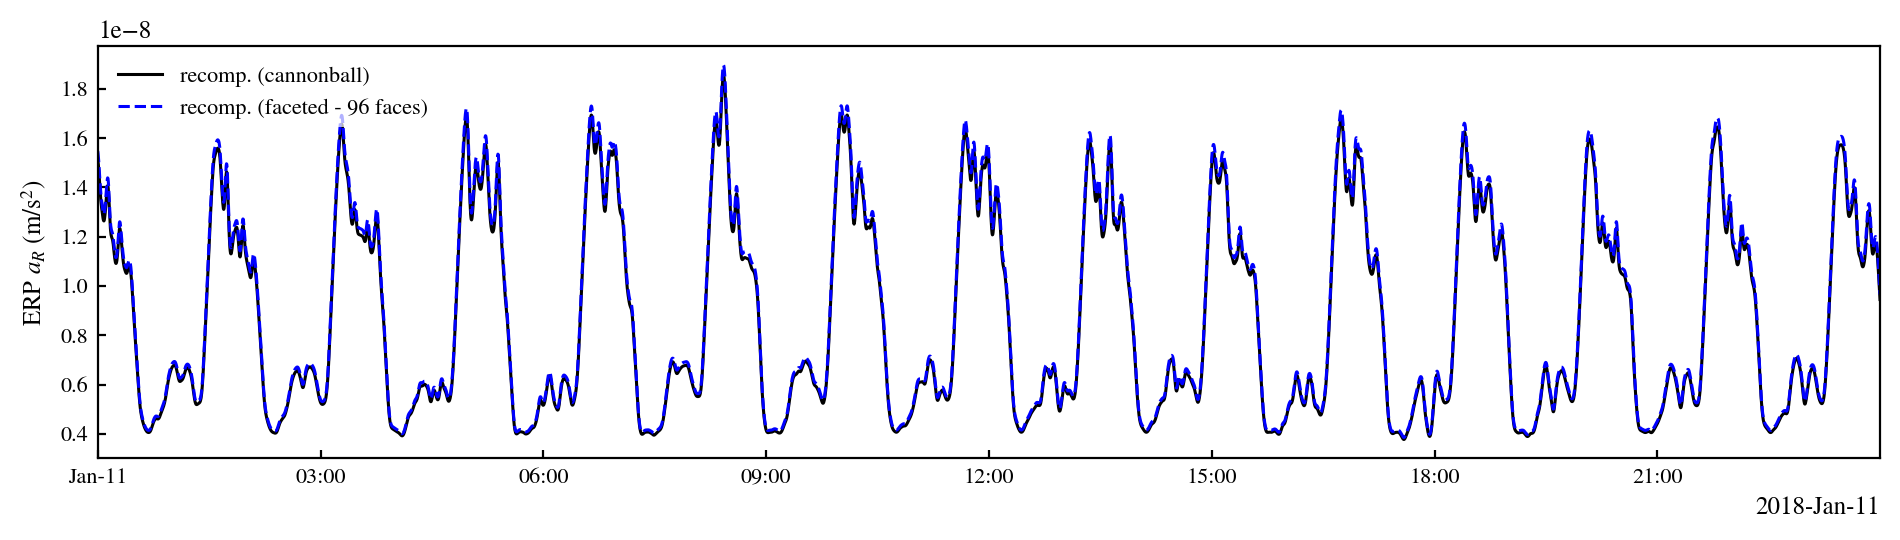

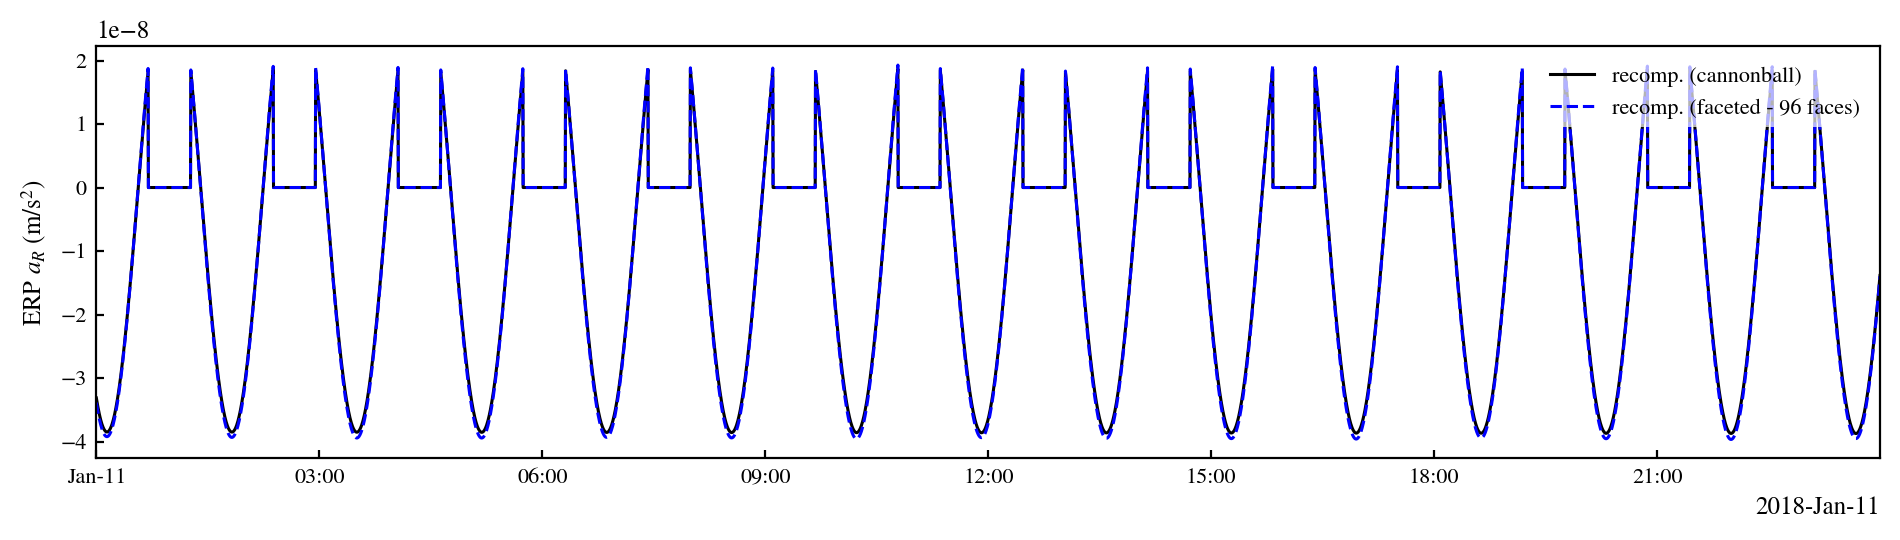

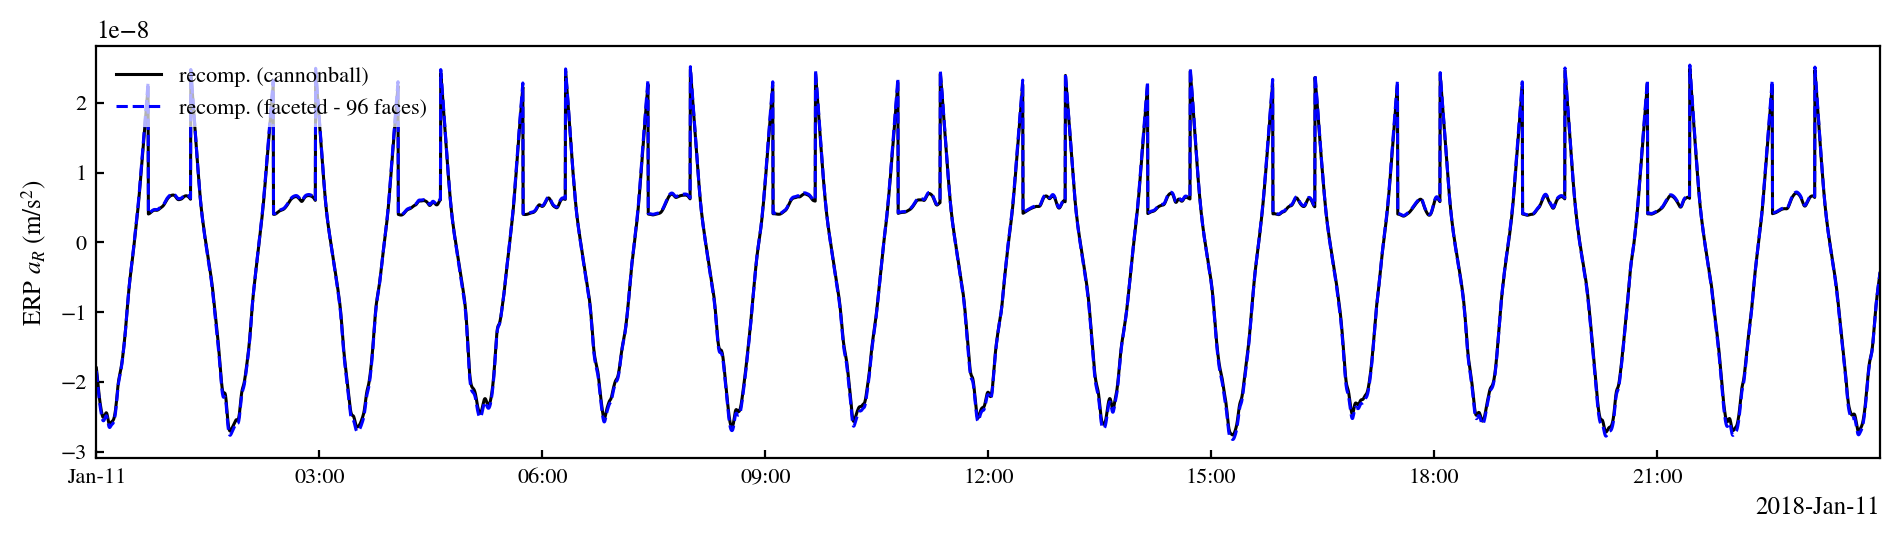

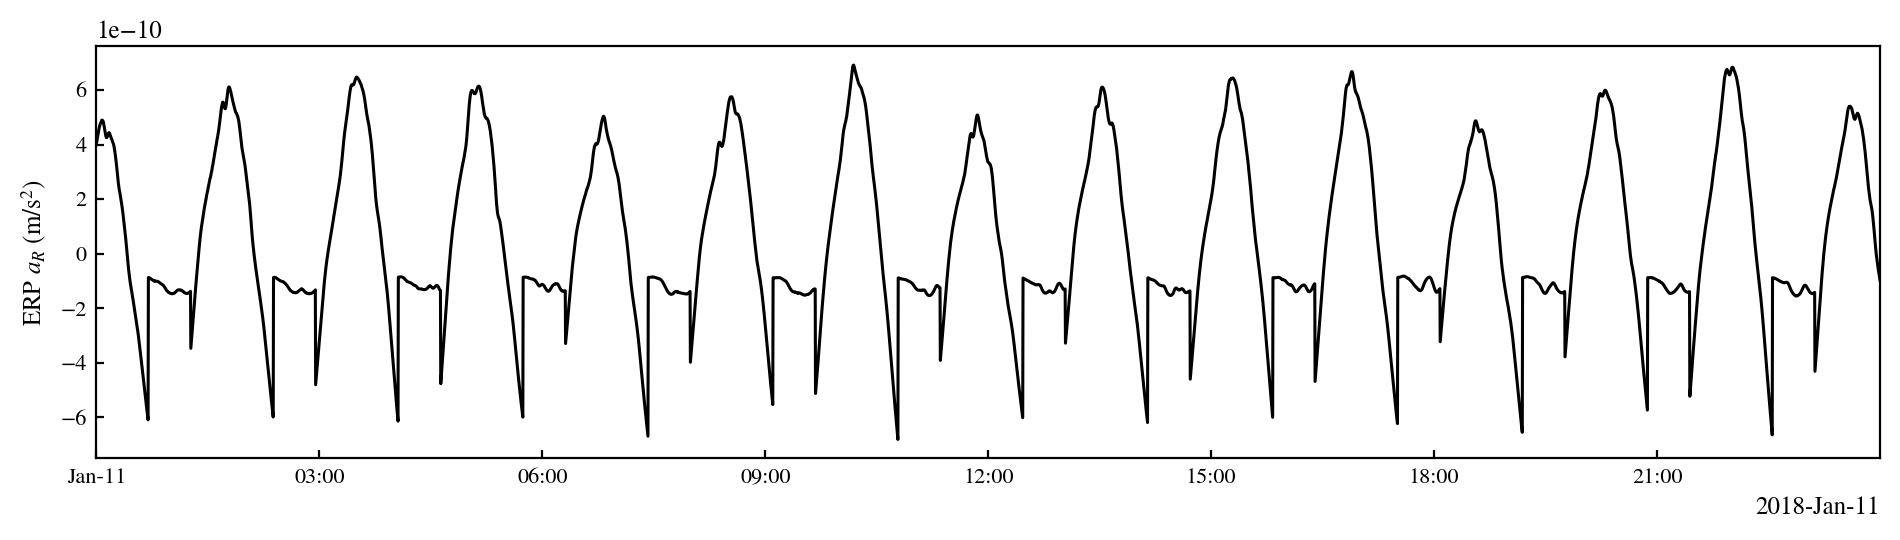

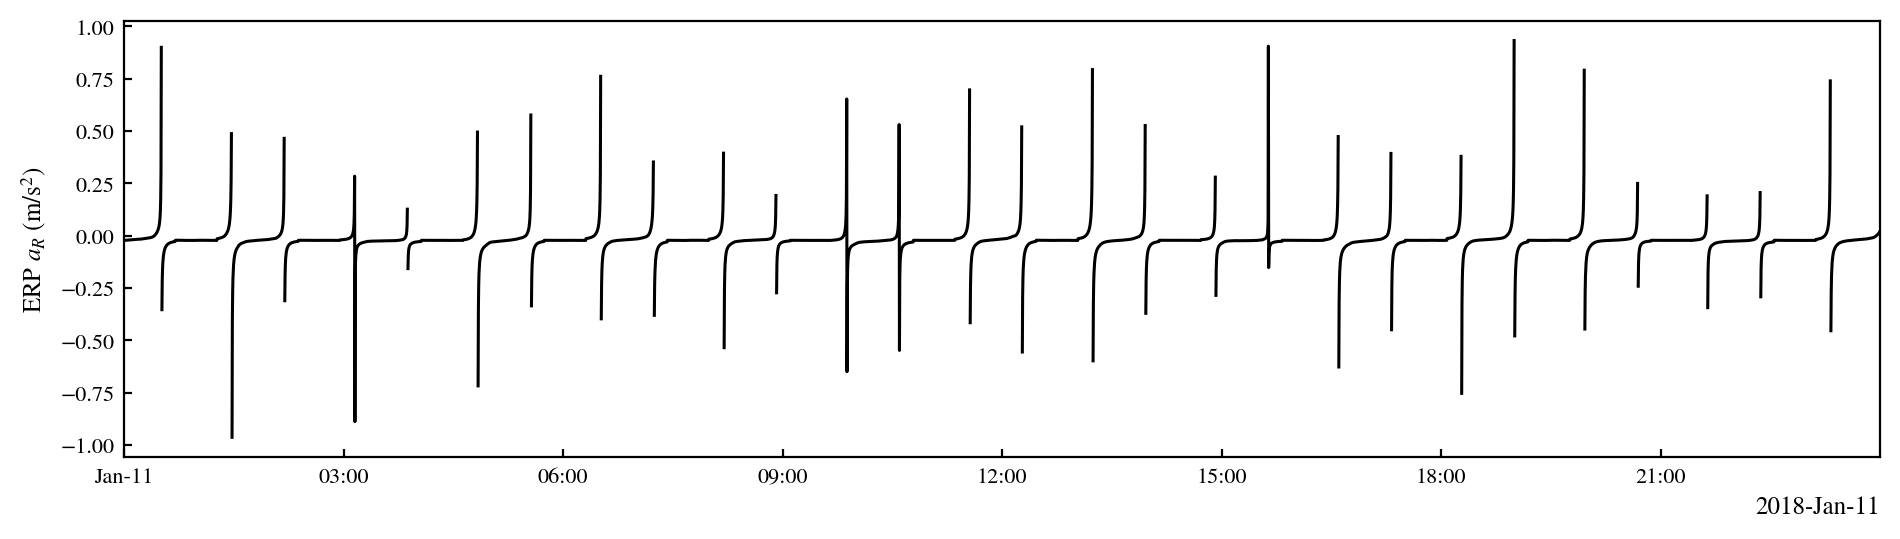

In [ ]:
# testing the new recomp functions

import numpy as np
from scipy.stats import uniform_direction
import sys, os
from SpaceBalls.radiation_settings import radiation_settings_from_EEI_truth_name
from SpaceBalls.postproc_EEI_estimation import get_acc_to_flux_factor, get_true_EEI_time_series, estimate_EEI_avg #, get_all_orbital_sma_0, get_stacked_avg_maps_3D_mode
from SpaceBalls.radiation_fluxes_preprocessing import compute_a_hist_at_sat_r_hist, compute_F_hist_at_sat_r_hist, F_vec_to_Fr, get_norm_across_last_dim, get_EEI_truth_daily_jd_arrays, get_mid_day_jd_array, get_toa_grid_from_rad_config
from SpaceBalls.utils import normal_smoother, progress_bar, nanrms, get_Rotation

import SpaceBalls.input_database_manager as input_manager
from SpaceBalls.sph_meshing import get_faceted_sphere_mesh, QuadratureGrid, KnockeGridMONTE, RegularLatLonGrid
from SpaceBalls.plotter import Plotter
import SpaceBalls.constants as constants
import itertools
import time
import random
from SpaceBalls.paths import CONFIG_DIR, MEDIA_DIR, INPUT_DIR, OUTPUT_DIR
LIGHT_SPEED = constants.light_speed()

def get_random_vectors(n):
    return uniform_direction.rvs(dim=3, size=n)


def get_avg_cross_sectional_area(normal_vecs, areas):

    all_areas = []
    all_s = -get_random_vectors(10000)

    for i, s in enumerate(all_s):
        total_A = 0
        for i, (n, area) in enumerate(zip(normal_vecs, areas)):
            cos = np.max([0, np.dot(-s, n)])
            total_A += area * cos
        #print(f"cos gamma: {cos}")

        all_areas.append(total_A)
    
    return np.mean(all_areas)

desired_sb = {
    'force_settings': 2,
    'integration_settings': 110,  # 0 for GRACE-FO_orbit
    'orbit_name': 'Ajisai_orbit', # 'GRACE-FO_orbit', # 'LAGEOS_orbit', #'GRACE-FO_orbit',
    'delta_t_out': 15,
}

keys = input_manager.get_primary_keys(desired_sb)
#keys = [key for key in keys if 'LAGEOS' not in key]
assert(len(keys)==1)
sb_tag = keys[0]

sb_tag = 'SB_R800_21'  # 'GRACE-FO_spherical' # 'LAGEOS_119' # 'SB_R800_3'

#EEI_truth = input_manager.get_dicts(sb_tag)['force_settings']['EEI_truth']
EEI_truth = 'EEI_truth_35' # + str(EEI_truth)
grid = get_toa_grid_from_rad_config(radiation_settings_from_EEI_truth_name(EEI_truth))

n_days = 1
start_idx = 10
day_idxs = range(start_idx, start_idx+n_days)
all_jd = [None] * n_days
all_erp = [None] * n_days
all_erp_recomp_plated = [None] * n_days
all_erp_recomp_cannonball = [None] * n_days
all_srp = [None] * n_days
all_srp_recomp_plated = [None] * n_days
all_srp_recomp_cannonball = [None] * n_days

spin_f = 0.015 # [Hz]
spin_w = 2 * np.pi * spin_f
theta_0 = 0

sb_og_dict = input_manager.get_dicts(sb_tag)
mass = sb_og_dict['sc_params']['mass']
area = sb_og_dict['sc_params']['area']
sat_radius = np.sqrt(area/np.pi)
n_faces = 96
mesh = get_faceted_sphere_mesh(sat_radius, n_faces, default_golden=False)
vertices, centroids, normal_vecs, areas, edge_conns, hull = mesh
true_avg_area = get_avg_cross_sectional_area(normal_vecs, areas)

ca_SW = 0.12
cd_SW = 0.2
cs_SW = 0.68
sat_dict = {'mass': mass,
            'coeff_wl_split': False,
            'plate_normals': normal_vecs,
            'plate_areas': areas,
            'plate_ca_SW': ca_SW * np.ones(n_faces),
            'plate_cd_SW': cd_SW * np.ones(n_faces),
            'plate_cs_SW': cd_SW * np.ones(n_faces)
            }
avg_ca_SW = np.sum(sat_dict['plate_ca_SW']*sat_dict['plate_areas']) / np.sum(sat_dict['plate_areas'])
avg_cd_SW = np.sum(sat_dict['plate_cd_SW']*sat_dict['plate_areas']) / np.sum(sat_dict['plate_areas'])
avg_cs_SW = np.sum(sat_dict['plate_cs_SW']*sat_dict['plate_areas']) / np.sum(sat_dict['plate_areas'])

F_to_a = sat_dict['area'] / sat_dict['mass'] * (avg_ca_SW + avg_cs_SW + 13*avg_cd_SW/9) / LIGHT_SPEED
F_to_a_monte = 1/get_acc_to_flux_factor(sb_tag)

for i, day_idx in enumerate(day_idxs):

    r_hist_day = np.load(os.path.join(OUTPUT_DIR, sb_tag, 'day_'+str(day_idx), 'xyz_ecef.npy'))
    u_hist_day = r_hist_day/get_norm_across_last_dim(r_hist_day)[...,None]
    jd_hist_day = np.load(os.path.join(OUTPUT_DIR, sb_tag, 'day_'+str(day_idx), 'jd_vec.npy'))
    all_jd[i] = jd_hist_day

    erp_ar_hist = np.load(os.path.join(OUTPUT_DIR, sb_tag, 'day_'+str(day_idx), 'erp.npy'))[:,0] * 1e3
    all_erp[i] = erp_ar_hist

    srp_ar_hist = np.load(os.path.join(OUTPUT_DIR, sb_tag, 'day_'+str(day_idx), 'srp.npy'))[:,0] * 1e3
    all_srp[i] = srp_ar_hist

    # rotation axis in the direction of the orbit angular momentum
    v_hist_day = np.load(os.path.join(OUTPUT_DIR, sb_tag, 'day_'+str(day_idx), 'vxvyvz_ecef.npy'))
    h_hist_day = np.cross(r_hist_day, v_hist_day, axis=1)
    rot_axis_hist = h_hist_day / get_norm_across_last_dim(h_hist_day)[:,None]

    theta = theta_0 + spin_w * (jd_hist_day - jd_hist_day[0]) * 1/(24*3600)
    sat_R_body2ECEF_hist = get_Rotation(rot_axis=rot_axis_hist.T, theta_hist=theta).as_matrix()

    erp_a_hist, srp_a_hist = compute_a_hist_at_sat_r_hist(EEI_truth, 
                                                          sat_dict,
                                                          r_hist_day, 
                                                          jd_hist_day, 
                                                          toa_grid=grid,
                                                          sat_R_body2ECEF_hist=sat_R_body2ECEF_hist)
    all_erp_recomp_plated[i] = -np.squeeze(F_vec_to_Fr(erp_a_hist, u_hist_day[None,...]))
    all_srp_recomp_plated[i] = -np.squeeze(F_vec_to_Fr(srp_a_hist, u_hist_day[None,...]))

    erp_F_hist, srp_F_hist = compute_F_hist_at_sat_r_hist(EEI_truth, #'EEI_truth_1', 
                                                     r_hist_day, 
                                                     jd_hist_day, 
                                                     toa_grid=grid,
                                                     erp_wl_split=False)
    all_erp_recomp_cannonball[i] = F_to_a * np.squeeze(F_vec_to_Fr(erp_F_hist, u_hist_day[None,...]))
    all_srp_recomp_cannonball[i] = F_to_a * np.squeeze(F_vec_to_Fr(srp_F_hist, u_hist_day[None,...]))

    theta_0 = theta[-1] + np.mean(np.diff(theta)) # add slight dt to the start of next day

erp_cannonball = np.concatenate(all_erp_recomp_cannonball)
srp_cannonball = np.concatenate(all_srp_recomp_cannonball)
erp_plated = np.concatenate(all_erp_recomp_plated)
srp_plated = np.concatenate(all_srp_recomp_plated)

net_cannonball = erp_cannonball + srp_cannonball
net_plated = erp_plated + srp_plated

Plotter.plot_time_series(np.concatenate(all_jd), 
                         {#'MONTE': np.concatenate(all_erp),
                          'recomp. (cannonball)': erp_cannonball,
                          f"recomp. (faceted - {n_faces} faces)": erp_plated,
                          },
                         ylabel='ERP $a_R$ (m/s$^2$)',
                         f_width=2.4, f_height=0.7)

Plotter.plot_time_series(np.concatenate(all_jd), 
                         {#'MONTE': np.concatenate(all_erp),
                          'recomp. (cannonball)': srp_cannonball,
                          f"recomp. (faceted - {n_faces} faces)": srp_plated,
                          },
                         ylabel='ERP $a_R$ (m/s$^2$)',
                         f_width=2.4, f_height=0.7)

Plotter.plot_time_series(np.concatenate(all_jd), 
                         {#'MONTE': np.concatenate(all_erp),
                          'recomp. (cannonball)': net_cannonball,
                          f"recomp. (faceted - {n_faces} faces)": net_plated,
                          },
                         ylabel='ERP $a_R$ (m/s$^2$)',
                         f_width=2.4, f_height=0.7)

net_diff = net_cannonball-net_plated
Plotter.plot_time_series(np.concatenate(all_jd), 
                         {#'MONTE': np.concatenate(all_erp),
                          'recomp. net diff. (cannonball vs. {n_faces} faces)': net_diff,
                          },
                         ylabel='ERP $a_R$ (m/s$^2$)',
                         f_width=2.4, f_height=0.7)

net_rel_diff = net_diff / net_cannonball
net_rel_diff[np.abs(net_rel_diff)>1] = np.nan
Plotter.plot_time_series(np.concatenate(all_jd), 
                         {#'MONTE': np.concatenate(all_erp),
                          'recomp. net diff. (cannonball vs. {n_faces} faces)': net_rel_diff,
                          },
                         ylabel='ERP $a_R$ (m/s$^2$)',
                         f_width=2.4, f_height=0.7)